In [1]:
# Imports
from qiskit import *
from qiskit_aer import AerSimulator
%matplotlib inline

In [2]:
secret_number = "1000101"

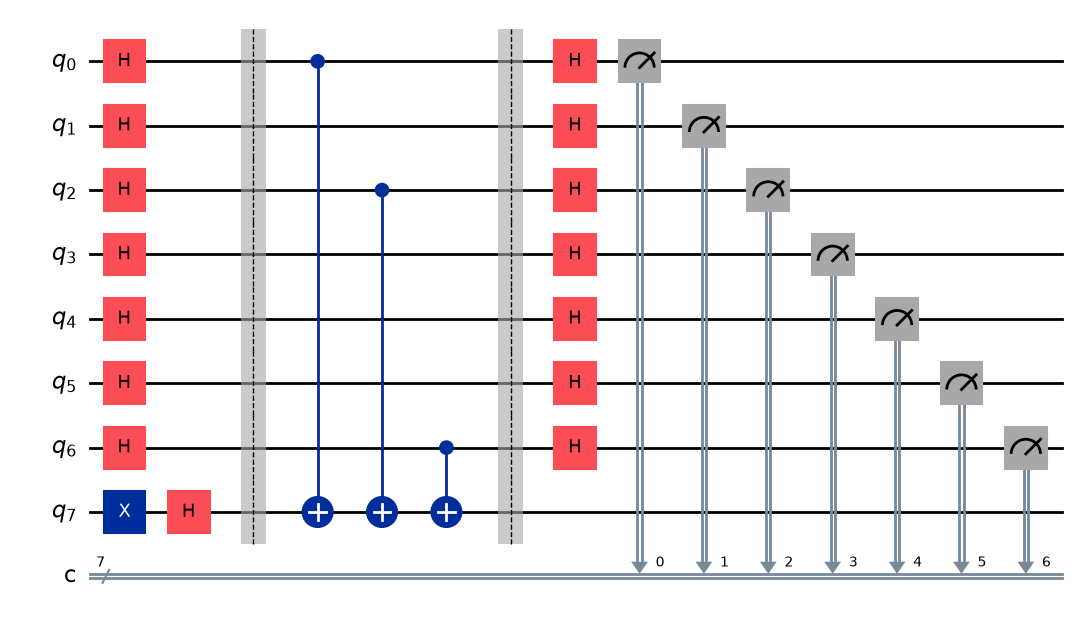

In [3]:
c = QuantumCircuit(8, 7)

c.h([0,1,2,3,4,5,6])
c.x(7)
c.h(7)
c.barrier()

# Manual implementation
c.cx(0, 7)
c.cx(2, 7)
c.cx(6, 7)
c.barrier()

c.h([0,1,2,3,4,5,6])
c.measure([0,1,2,3,4,5,6], [0,1,2,3,4,5,6])

c.draw(output="mpl");

In [4]:
simulator = AerSimulator()
result = simulator.run(c, shots=1).result()
counts = result.get_counts()

In [5]:
print(counts)

{'1000101': 1}


In [9]:
secret_number = "10010101"

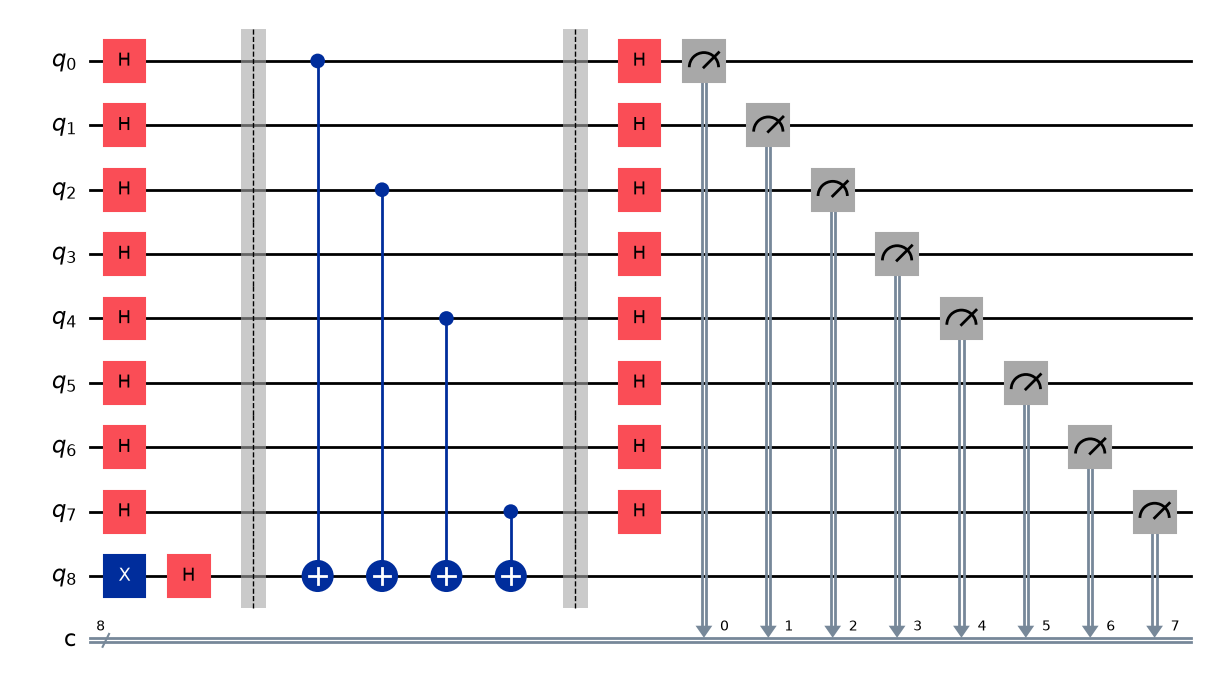

In [10]:
# Automatic implementation for string with n bits
num_classical_bits = len(secret_number)
num_qubits = num_classical_bits + 1
c = QuantumCircuit(num_qubits, num_classical_bits)

c.h([i for i in range(num_classical_bits)])
c.x(num_classical_bits)
c.h(num_classical_bits)
c.barrier()

# Black box oracle
for index, bit in enumerate(secret_number[::-1]):
    if bit == "1":
        c.cx(index, num_classical_bits)
        
c.barrier()

c.h([i for i in range(num_classical_bits)])
c.measure([i for i in range(num_classical_bits)], [i for i in range(num_classical_bits)])

c.draw(output="mpl");

In [11]:
simulator = AerSimulator()
result = simulator.run(c, shots=1).result()
counts = result.get_counts()

In [12]:
print(counts)

{'10010101': 1}
